In [47]:
import pandas as pd
import numpy as np
import altair as alt

In [48]:
from pathlib import Path
import re

# Lightly clean city names (trim whitespace/punctuation)
def normalize_city(name: str) -> str:
    if pd.isna(name):
        return None
    s = str(name)
    s = s.replace("\ufeff", "").strip()
    s = s.strip("'\"")
    s = s.replace("’", "'")
    s = re.sub(r"\s*/\s*", "/", s)
    s = re.sub(r"\s*-+\s*", "-", s)
    s = re.sub(r"\s+", " ", s)
    return s

# Aggregate municipal accident data across 15 yearly city files
# Assumes files named "Road accidents with injuries ... (cities) (x).csv" with x=1..15 in data/.
data_dir = Path("c:/Users/juanx/Documents/GitHub/juanxgi83.github.io/data")
city_files = sorted(data_dir.glob("Road accidents with injuries* (cities) (*.csv"))
if len(city_files) != 15:
    raise FileNotFoundError(f"Expected 15 city files, found {len(city_files)}")

raw_parts = []
for fp in city_files:
    part = pd.read_csv(fp)
    raw_parts.append(part)
raw = pd.concat(raw_parts, ignore_index=True)

# Keep descriptive columns and the observation
col_map = {
    "Territory": "city",
    "Localization of the accident": "localization",
    "Intersection (DESC)": "intersection",
    "Road accident type": "accident_type",
    "Deadly accident": "deadly",  # categorical flag
    "Road accident hour": "hour_band",
    "Week day": "weekday",
    "Month (DESC)": "month",
    "Observation": "value",
}
needed = list(col_map.keys())
missing = [c for c in needed if c not in raw.columns]
if missing:
    raise KeyError(f"Missing expected columns: {missing}")

acc = raw[needed].rename(columns=col_map)
acc["value"] = pd.to_numeric(acc["value"], errors="coerce").fillna(0)
acc["city"] = acc["city"].apply(normalize_city)
acc = acc.dropna(subset=["city"])

# Build compact, descriptive variable labels (skip dims that are "Total")
label_parts = [
    ("localization", "loc"),
    ("intersection", "intersection"),
    ("accident_type", "type"),
    ("deadly", "fatality"),
    ("hour_band", "hour"),
    ("weekday", "weekday"),
    ("month", "month"),
]

def make_label(row):
    parts = []
    for col, short in label_parts:
        val = str(row[col]).strip()
        if val.lower() == "total":
            continue
        parts.append(f"{short}={val}")
    return " | ".join(parts) if parts else None

acc["variable"] = acc.apply(make_label, axis=1)
acc = acc.dropna(subset=["variable"])  # drop all_categories rows

# Sum across the 15 years by city and variable, then pivot wide
agg = acc.groupby(["city", "variable"], as_index=False)["value"].sum()
wide = (
    agg
    .pivot(index="city", columns="variable", values="value")
    .fillna(0)
)

# Keep only three-dimension combos and the city total
cols = list(wide.columns)
three_dim = [c for c in cols if isinstance(c, str) and c.count(" | ") == 2]
three_dim_sorted = sorted(three_dim)
wide = wide[three_dim_sorted]
wide["city_total_15y"] = wide.sum(axis=1)

# Percent share of each combo vs city_total_15y
acc_den = wide["city_total_15y"].replace({0: pd.NA})
wide_pct = wide[three_dim_sorted].div(acc_den, axis=0).fillna(0)
wide_pct.columns = [f"%{c}" for c in three_dim_sorted]
wide = pd.concat([wide, wide_pct], axis=1)

accidents_city_df = wide.reset_index()

# ---------------- Vehicle register (single Level 3 file, 15 years 2010-2024) -----------------
veh_fp = data_dir / "Vehicles - Public automotive register (IT1,41_288_DF_DCIS_VEICOLIPRA_1,1.0) (Level 3).csv"
veh_raw = pd.read_csv(veh_fp)

veh_needed = ["Territory", "Vehicle type", "TIME_PERIOD", "Observation"]
veh_missing = [c for c in veh_needed if c not in veh_raw.columns]
if veh_missing:
    raise KeyError(f"Missing expected vehicle columns: {veh_missing}")

veh = veh_raw[veh_needed].rename(columns={
    "Territory": "city",
    "Vehicle type": "vehicle_type",
    "TIME_PERIOD": "year",
    "Observation": "value",
})
veh = veh[(veh["year"] >= 2010) & (veh["year"] <= 2024)]
veh["value"] = pd.to_numeric(veh["value"], errors="coerce").fillna(0)
veh["city"] = veh["city"].apply(normalize_city)
veh = veh.dropna(subset=["city"])

# Average per city and vehicle type over the 15 years
veh_avg = veh.groupby(["city", "vehicle_type"], as_index=False)["value"].mean()

def clean_name(name: str) -> str:
    name = name.strip()
    name = re.sub(r"[^0-9A-Za-z]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name.lower()

veh_avg["vehicle_col"] = veh_avg["vehicle_type"].apply(clean_name)
veh_wide = veh_avg.pivot(index="city", columns="vehicle_col", values="value").fillna(0)
veh_wide = veh_wide.rename(columns={c: ("avg_" + c + "_15y") for c in veh_wide.columns})

# Normalise total column name if present
for candidate in ["avg_total_15y", "avg_totale_15y", "avg_total_vehicles_15y"]:
    if candidate in veh_wide.columns:
        veh_wide = veh_wide.rename(columns={candidate: "avg_total_vehicles_15y"})

veh_cols = list(veh_wide.columns)
non_total = sorted([c for c in veh_cols if c != "avg_total_vehicles_15y"])
ordered = non_total + (["avg_total_vehicles_15y"] if "avg_total_vehicles_15y" in veh_cols else [])
veh_wide = veh_wide[ordered]

# Percent share of each vehicle type vs avg_total_vehicles_15y
if "avg_total_vehicles_15y" in veh_wide.columns:
    veh_den = veh_wide["avg_total_vehicles_15y"].replace({0: pd.NA})
    veh_pct_cols = [c for c in ordered if c != "avg_total_vehicles_15y"]
    veh_pct = veh_wide[veh_pct_cols].div(veh_den, axis=0).fillna(0)
    veh_pct.columns = [f"%{c}" for c in veh_pct_cols]
    veh_wide = pd.concat([veh_wide, veh_pct], axis=1)

# Merge accidents + vehicles
combined_df = accidents_city_df.merge(veh_wide, on="city", how="left")

# Export to Excel
excel_out = data_dir / "municipal_accident_totals_15y.xlsx"
try:
    combined_df.to_excel(excel_out, index=False)
except PermissionError:
    print("Warning: could not write Excel (file locked)")

# Grand total across cities for accidents (city_total_15y)
city_total_grand = combined_df["city_total_15y"].sum()
print(city_total_grand)

# Sum of avg total vehicles across cities
if "avg_total_vehicles_15y" in combined_df.columns:
    total_avg_vehicles = combined_df["avg_total_vehicles_15y"].sum()
    print(total_avg_vehicles)

excel_out

combined_df.head()

2611504.0
51634264.007142864


,city,loc=Motorway | intersection=Bend | type=Accidents between vehicles,loc=Motorway | intersection=Bend | type=Accidents involving a single vehicle,loc=Motorway | intersection=Bend | type=Vehicle-pedestrian accident,loc=Motorway | intersection=Bump - slope - bottleneck | type=Accidents between vehicles,loc=Motorway | intersection=Bump - slope - bottleneck | type=Accidents involving a single vehicle,loc=Motorway | intersection=Bump - slope - bottleneck | type=Vehicle-pedestrian accident,loc=Motorway | intersection=Crossoroad | type=Accidents between vehicles,loc=Motorway | intersection=Straight stretch | type=Accidents between vehicles,loc=Motorway | intersection=Straight stretch | type=Accidents involving a single vehicle,...,avg_trucks_15y,avg_total_vehicles_15y,%avg_bus_or_trolley_bus_15y,%avg_motor_cars_15y,%avg_motor_units_15y,%avg_motorcycles_15y,%avg_other_vehicles_15y,%avg_three_wheeler_or_motor_van_15y,%avg_trailer_15y,%avg_trucks_15y
0,Agrigento,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,39581.533333,381878.133333,0.001633,0.749968,0.002928,0.125609,5.237273e-07,0.010053,0.006159,0.103650
1,Alessandria,146.0,262.0,1.0,0.0,0.0,0.0,0.0,898.0,463.0,...,40127.266667,384282.600000,0.001628,0.739174,0.007027,0.127162,0.000000e+00,0.006685,0.013903,0.104421
2,Ancona,87.0,88.0,3.0,2.0,1.0,1.0,0.0,331.0,161.0,...,37538.133333,412489.266667,0.001584,0.740241,0.002251,0.155476,0.000000e+00,0.004116,0.005327,0.091004
3,Arezzo,93.0,96.0,1.0,1.0,2.0,0.0,0.0,462.0,175.0,...,30058.933333,316197.466667,0.002998,0.751212,0.002015,0.135548,2.108387e-07,0.008280,0.004883,0.095064
4,Ascoli Piceno,60.0,76.0,1.0,4.0,0.0,0.0,0.0,434.0,179.0,...,18147.200000,191740.200000,0.002371,0.746531,0.004584,0.139069,0.000000e+00,0.004382,0.008417,0.094645


In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Build feature matrix from percentage columns only
pct_cols = [c for c in combined_df.columns if isinstance(c, str) and c.startswith("%")]
if not pct_cols:
    raise ValueError("No percentage columns found; rerun aggregation cell to create % columns.")

X = combined_df[pct_cols].fillna(0)

# Standardise features (zero mean, unit variance)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Prepare PCA (scores) for downstream use
pca = PCA()
X_pca = pca.fit_transform(X_std)

# Keep city labels alongside matrices for reference
cities = combined_df["city"].tolist()

# Optional: quick shape/variance checks
print("X_std shape", X_std.shape)
print("PCA explained variance ratio (first 5)", pca.explained_variance_ratio_[:5])

X_std shape (111, 65)
PCA explained variance ratio (first 5) [0.16873908 0.13201471 0.07926399 0.06198963 0.04969209]


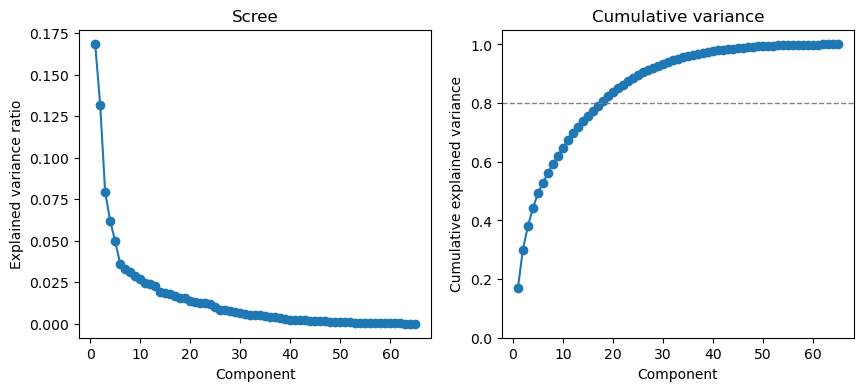

c:\Users\juanx\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\juanx\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\juanx\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\juanx\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than 

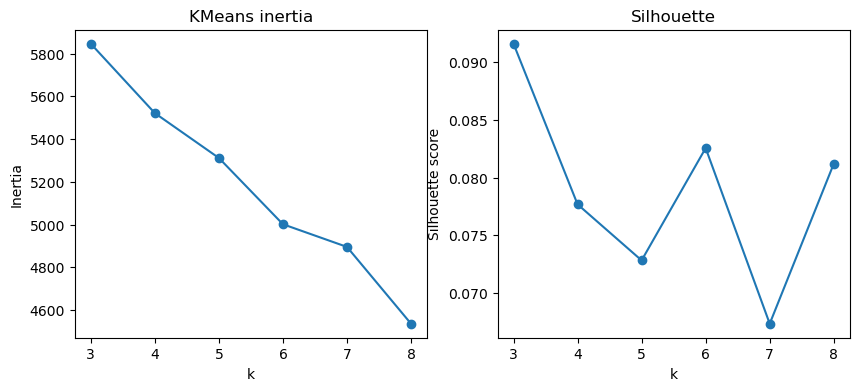

Chosen k (silhouette): 3


c:\Users\juanx\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



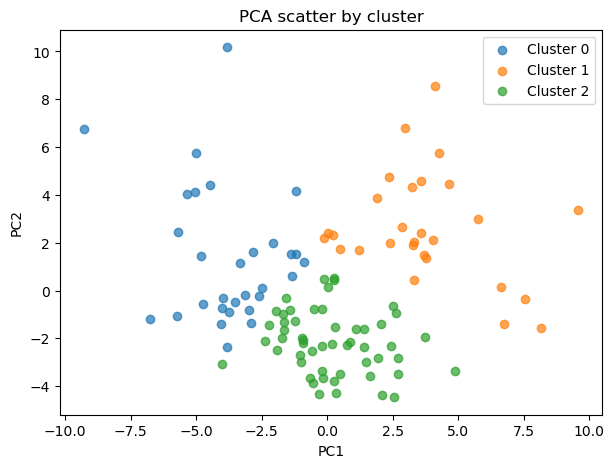

Cluster sizes: {0: 30, 1: 28, 2: 53}


,%loc=Motorway | intersection=Bend | type=Accidents between vehicles,%loc=Motorway | intersection=Bend | type=Accidents involving a single vehicle,%loc=Motorway | intersection=Bend | type=Vehicle-pedestrian accident,%loc=Motorway | intersection=Bump - slope - bottleneck | type=Accidents between vehicles,%loc=Motorway | intersection=Bump - slope - bottleneck | type=Accidents involving a single vehicle,%loc=Motorway | intersection=Bump - slope - bottleneck | type=Vehicle-pedestrian accident,%loc=Motorway | intersection=Crossoroad | type=Accidents between vehicles,%loc=Motorway | intersection=Straight stretch | type=Accidents between vehicles,%loc=Motorway | intersection=Straight stretch | type=Accidents involving a single vehicle,%loc=Motorway | intersection=Straight stretch | type=Vehicle-pedestrian accident,...,%loc=Urban road | intersection=Tunnel | type=Accidents involving a single vehicle,%loc=Urban road | intersection=Tunnel | type=Vehicle-pedestrian accident,%avg_bus_or_trolley_bus_15y,%avg_motor_cars_15y,%avg_motor_units_15y,%avg_motorcycles_15y,%avg_other_vehicles_15y,%avg_three_wheeler_or_motor_van_15y,%avg_trailer_15y,%avg_trucks_15y
cluster_kmeans,,,,,,,,,,,,,,,,,,,,,
0,0.007335,0.010133,0.000061,0.000176,0.000098,0.000006,0.000005,0.028865,0.010531,0.000240,...,0.000523,0.000084,0.001612,0.727231,0.002893,0.166585,7.817137e-07,0.007658,0.006139,0.087881
1,0.006385,0.008969,0.000048,0.000205,0.000172,0.000000,0.000000,0.022226,0.011322,0.000217,...,0.000183,0.000042,0.002447,0.760645,0.003615,0.100757,7.733892e-07,0.011703,0.007895,0.112939
2,0.002005,0.002480,0.000017,0.000068,0.000029,0.000002,0.000003,0.019243,0.008188,0.000168,...,0.000262,0.000037,0.001837,0.755469,0.003939,0.120381,1.367430e-06,0.006890,0.008894,0.101813


In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Use only percentage columns
pct_cols_all = [c for c in combined_df.columns if isinstance(c, str) and c.startswith("%")]
if not pct_cols_all:
    raise ValueError("No percentage columns found; rerun previous cells to create % columns.")

# Drop zero-variance features
X_df = combined_df[pct_cols_all]
stds = X_df.std(axis=0)
pct_cols_use = [c for c in pct_cols_all if stds[c] > 0]
if not pct_cols_use:
    raise ValueError("All % columns have zero variance.")

X_use = X_df[pct_cols_use].fillna(0)

# Standardize
scaler_clu = StandardScaler()
X_std_use = scaler_clu.fit_transform(X_use)

# PCA diagnostics
pca_full = PCA()
pca_full.fit(X_std_use)
ev = pca_full.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(range(1, len(ev) + 1), ev, marker="o")
axes[0].set_title("Scree")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained variance ratio")
axes[1].plot(range(1, len(ev) + 1), np.cumsum(ev), marker="o")
axes[1].axhline(0.8, color="gray", linestyle="--", linewidth=1)
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Cumulative variance")
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Cumulative explained variance")
plt.show()

# KMeans model selection
k_range = range(3, 9)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_std_use)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_std_use, km.labels_) if X_std_use.shape[0] > k else np.nan)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("KMeans inertia")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), silhouettes, marker="o")
axes[1].set_title("Silhouette")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
plt.show()

valid_pairs = [(k, s) for k, s in zip(k_range, silhouettes) if not np.isnan(s)]
best_k = max(valid_pairs, key=lambda t: t[1])[0] if valid_pairs else 3
print(f"Chosen k (silhouette): {best_k}")

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = km_final.fit_predict(X_std_use)
combined_df["cluster_kmeans"] = clusters

# 2D PCA scatter for visualization
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_std_use)
scatter_df = pd.DataFrame({
    "pc1": X_pca2[:, 0],
    "pc2": X_pca2[:, 1],
    "cluster": clusters,
    "city": combined_df["city"],
    "city_total_15y": combined_df["city_total_15y"],
})

plt.figure(figsize=(7, 5))
for cl in sorted(scatter_df["cluster"].unique()):
    sub = scatter_df[scatter_df["cluster"] == cl]
    plt.scatter(sub["pc1"], sub["pc2"], label=f"Cluster {cl}", alpha=0.7)
plt.title("PCA scatter by cluster")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

# Cluster centroids for percent features
centroids = combined_df.groupby("cluster_kmeans")[pct_cols_use].mean()
print("Cluster sizes:", combined_df["cluster_kmeans"].value_counts().sort_index().to_dict())
display(centroids)


In [83]:
# PCA biplot (Altair): cities as points, top loadings as arrows
# Uses existing PC1/PC2 scores (scatter_df) and PCA loadings from pca2
loadings = (
    pd.DataFrame(pca2.components_.T, index=pct_cols_use, columns=["pc1_loading", "pc2_loading"])
    .reset_index()
    .rename(columns={"index": "feature"})
)
loadings["absmax"] = loadings[["pc1_loading", "pc2_loading"]].abs().max(axis=1)
# Fewer arrows to reduce clutter
loadings_top = loadings.nlargest(8, "absmax")
arrow_scale = 2.0
loadings_top["pc1_arrow"] = loadings_top["pc1_loading"] * arrow_scale
loadings_top["pc2_arrow"] = loadings_top["pc2_loading"] * arrow_scale

# Shared color scale for clusters (royal blue first)
cluster_scale = alt.Scale(
    range=[
        "royalblue",
        "#e45756",
        "#72b7b2",
        "#f58518",
        "#54a24b",
        "#eeca3b",
        "#b279a2",
        "#ff9da6",
        "#9c755f",
        "#bab0ab",
    ]
)

points = (
    alt.Chart(scatter_df)
    .mark_circle(opacity=0.7, stroke="black", strokeWidth=0.3)
    .encode(
        x=alt.X("pc1", title="PC1"),
        y=alt.Y("pc2", title="PC2"),
        color=alt.Color("cluster:N", scale=cluster_scale, legend=alt.Legend(title="Cluster")),
        size=alt.Size("city_total_15y", title="City total (15y)", scale=alt.Scale(range=[40, 1400])),
        tooltip=["city", "cluster:N", alt.Tooltip("city_total_15y", format=",")],
    )
    .properties(width=900, height=360)
)

# Arrows from origin to scaled loading tip (typed x/y to avoid Vega-Lite type errors)
arrows = (
    alt.Chart(loadings_top)
    .mark_rule(color="#444", opacity=0.8)
    .encode(
        x=alt.X("pc1_arrow:Q", title="PC1 loading"),
        x2=alt.value(0),
        y=alt.Y("pc2_arrow:Q", title="PC2 loading"),
        y2=alt.value(0),
        tooltip=["feature", alt.Tooltip("pc1_loading", format=".3f"), alt.Tooltip("pc2_loading", format=".3f")],
    )
)

arrow_labels = (
    alt.Chart(loadings_top)
    .mark_text(dx=6, dy=0, align="left", fontSize=10, color="#222")
    .encode(
        x="pc1_arrow:Q",
        y="pc2_arrow:Q",
        text="feature",
    )
)

biplot = (points + arrows + arrow_labels).properties(
    title="PCA biplot (PC1 vs PC2): cities and top feature loadings"
)

biplot

alt.LayerChart(...)

In [92]:
import numpy as np
import plotly.graph_objects as go

# Plotly version of the PCA biplot (interactive)
# Recompute loadings to keep this cell self-contained
plotly_arrow_scale = 32.0  # make arrows far longer
top_n = 5
plotly_loadings = (
    pd.DataFrame(pca2.components_.T, index=pct_cols_use, columns=["pc1_loading", "pc2_loading"])
)
plotly_loadings = plotly_loadings.reset_index().rename(columns={"index": "feature"})
plotly_loadings["absmax"] = plotly_loadings[["pc1_loading", "pc2_loading"]].abs().max(axis=1)
plotly_top = plotly_loadings.nlargest(top_n, "absmax")
plotly_top["pc1_arrow"] = plotly_top["pc1_loading"] * plotly_arrow_scale
plotly_top["pc2_arrow"] = plotly_top["pc2_loading"] * plotly_arrow_scale

# Color palette (matches Altair)
plotly_palette = [
    "royalblue",
    "#e45756",
    "#72b7b2",
    "#f58518",
    "#54a24b",
    "#eeca3b",
    "#b279a2",
    "#ff9da6",
    "#9c755f",
    "#bab0ab",
]
cluster_colors_plotly = {int(cl): plotly_palette[int(cl) % len(plotly_palette)] for cl in np.unique(scatter_df["cluster"])}

# Bubble scatter with sane sizing
size_vals = np.sqrt(np.clip(scatter_df["city_total_15y"].to_numpy(), a_min=0, a_max=None))
max_marker_px = 24
sizeref = 2.0 * size_vals.max() / (max_marker_px ** 2) if size_vals.max() > 0 else 1.0
fig_biplot = go.Figure()
fig_biplot.add_trace(
    go.Scatter(
        x=scatter_df["pc1"],
        y=scatter_df["pc2"],
        mode="markers",
        marker=dict(
            size=size_vals,
            sizemode="area",
            sizeref=sizeref,
            sizemin=4,
            color=[cluster_colors_plotly[int(c)] for c in scatter_df["cluster"]],
            line=dict(color="black", width=0.4),
            opacity=0.7,
        ),
        text=scatter_df["city"],
        customdata=np.stack([scatter_df["cluster"], scatter_df["city_total_15y"]], axis=-1),
        hovertemplate=("City: %{text}<br>Cluster: %{customdata[0]}<br>City total (15y): %{customdata[1]:,.0f}<extra></extra>"),
        showlegend=False,
    )
)

# Arrows and labels for top loadings (limited to top_n to reduce clutter)
for _, row in plotly_top.iterrows():
    fig_biplot.add_trace(
        go.Scatter(
            x=[0, row["pc1_arrow"]],
            y=[0, row["pc2_arrow"]],
            mode="lines",
            line=dict(color="#222", width=3),
            hovertemplate=(
                f"Feature: {row['feature']}<br>PC1 loading: {row['pc1_loading']:.3f}<br>PC2 loading: {row['pc2_loading']:.3f}<extra></extra>"
            ),
            showlegend=False,
        )
    )
    # Arrowhead via annotation from origin to tip
    fig_biplot.add_annotation(
        x=row["pc1_arrow"],
        y=row["pc2_arrow"],
        ax=0,
        ay=0,
        xref="x",
        yref="y",
        axref="x",
        ayref="y",
        showarrow=True,
        arrowhead=3,
        arrowsize=1.2,
        arrowwidth=2.5,
        arrowcolor="#222",
        text="",
    )
    # Offset labels away from the arrow tip based on quadrant
    xshift = 10 if row["pc1_arrow"] >= 0 else -10
    yshift = 8 if row["pc2_arrow"] >= 0 else -8
    fig_biplot.add_annotation(
        x=row["pc1_arrow"],
        y=row["pc2_arrow"],
        text=row["feature"],
        showarrow=False,
        xanchor="left" if row["pc1_arrow"] >= 0 else "right",
        yanchor="middle",
        font=dict(color="#111", size=11),
        xshift=xshift,
        yshift=yshift,
        bgcolor="rgba(255,255,255,0.9)",
        bordercolor="#888",
        borderpad=3,
    )

# Extend x-axis to at least -40 on the left and 40 on the right, with padding
pc1_min = min(scatter_df["pc1"].min(), plotly_top["pc1_arrow"].min())
pc1_max = max(scatter_df["pc1"].max(), plotly_top["pc1_arrow"].max())
span = pc1_max - pc1_min
pad = 0.05 * span if span > 0 else 1
x_min = min(-40, pc1_min - pad)
x_max = max(40, pc1_max + pad)

fig_biplot.update_layout(
    title="PCA biplot (PC1 vs PC2): Plotly version",
    xaxis_title="PC1",
    yaxis_title="PC2",
    width=1000,
    height=520,
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(
        showgrid=True,
        gridcolor="#e0e0e0",
        zeroline=True,
        zerolinecolor="#a0a0a0",
        range=[x_min, x_max],
    ),
    yaxis=dict(showgrid=True, gridcolor="#e0e0e0", zeroline=True, zerolinecolor="#a0a0a0"),
)

fig_biplot.show()

In [72]:
import altair as alt

# Interactive layout: top row (inertia, silhouette), middle (scatter), bottom (city/cluster bars)
alt.data_transformers.disable_max_rows()

# Shared color scale for scatter (royal blue first)
cluster_scale = alt.Scale(
    range=[
        "royalblue",
        "#e45756",
        "#72b7b2",
        "#f58518",
        "#54a24b",
        "#eeca3b",
        "#b279a2",
        "#ff9da6",
        "#9c755f",
        "#bab0ab",
    ]
)

# Small charts for KMeans diagnostics
inertia_df = pd.DataFrame({"k": list(k_range), "inertia": inertias})
sil_df = pd.DataFrame({"k": list(k_range), "silhouette": silhouettes})

inertia_chart = (
    alt.Chart(inertia_df)
    .mark_line(point={"filled": True, "fill": "orange", "stroke": "orange"}, color="orange")
    .encode(
        x=alt.X("k:O", title="k", axis=alt.Axis(labelAngle=0)),
        y=alt.Y("inertia:Q", title="KMeans inertia"),
        tooltip=["k", alt.Tooltip("inertia:Q", format=",")],
    )
    .properties(width=420, height=200, title="Inertia by k")
)

silhouette_chart = (
    alt.Chart(sil_df)
    .mark_line(point={"filled": True, "fill": "orange", "stroke": "orange"}, color="orange")
    .encode(
        x=alt.X("k:O", title="k", axis=alt.Axis(labelAngle=0)),
        y=alt.Y("silhouette:Q", title="Silhouette score"),
        tooltip=["k", alt.Tooltip("silhouette:Q", format=".3f")],
    )
    .properties(width=420, height=200, title="Silhouette by k")
)

top_row = alt.hconcat(inertia_chart, silhouette_chart)

# Bubble scatter on PC1/PC2
scatter_data = scatter_df.copy()
scatter_data["size"] = np.sqrt(scatter_data["city_total_15y"].clip(lower=0))

city_select = alt.selection_point(fields=["city"], empty="none")
cluster_select = alt.selection_point(fields=["cluster"], empty="none")

scatter_chart = (
    alt.Chart(scatter_data)
    .mark_circle(opacity=0.65, stroke="black", strokeWidth=0.3)
    .encode(
        x=alt.X("pc1", title="PC1"),
        y=alt.Y("pc2", title="PC2"),
        size=alt.Size("size", legend=None, scale=alt.Scale(range=[50, 1500])),
        color=alt.Color("cluster:N", scale=cluster_scale, legend=alt.Legend(title="Cluster")),
        tooltip=["city", "cluster:N", alt.Tooltip("city_total_15y", format=",")],
    )
    .properties(width=900, height=360)
    .add_params(city_select, cluster_select)
)

# Long data for city-level % features (carry cluster for completeness)
pct_long = (
    X_use.assign(city=combined_df["city"], cluster=combined_df["cluster_kmeans"])
    .melt(id_vars=["city", "cluster"], var_name="feature", value_name="value")
)

bars_city = (
    alt.Chart(pct_long)
    .transform_filter(city_select)
    .transform_window(
        rank="rank(value)",
        sort=[alt.SortField("value", order="descending")],
        groupby=["city"],
    )
    .transform_filter("datum.rank <= 15")
    .mark_bar(color="orange")
    .encode(
        y=alt.Y("feature:N", sort="-x", title="Feature"),
        x=alt.X("value:Q", title="% share"),
        tooltip=["city", "feature", alt.Tooltip("value:Q", format=".2f")],
    )
    .properties(width=440, height=320, title="Selected city: top 15 % features")
)

# Cluster centroids long form
centroid_long = (
    centroids.reset_index().rename(columns={"cluster_kmeans": "cluster"})
    .melt(id_vars="cluster", var_name="feature", value_name="value")
)

bars_cluster = (
    alt.Chart(centroid_long)
    .transform_filter(cluster_select)
    .transform_window(
        rank="rank(value)",
        sort=[alt.SortField("value", order="descending")],
        groupby=["cluster"],
    )
    .transform_filter("datum.rank <= 15")
    .mark_bar(color="orange")
    .encode(
        y=alt.Y("feature:N", sort="-x", title="Feature"),
        x=alt.X("value:Q", title="Cluster mean %"),
        tooltip=["cluster:N", "feature", alt.Tooltip("value:Q", format=".2f")],
    )
    .properties(width=440, height=320, title="Selected cluster: top 15 % features")
)

bottom_row = alt.hconcat(bars_city, bars_cluster)

layout = alt.vconcat(top_row, scatter_chart, bottom_row).resolve_scale(color="independent")

layout

alt.VConcatChart(...)

In [63]:
from math import ceil
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree, fcluster
import plotly.graph_objects as go

# Plotly dendrogram with tooltips (Ward linkage on standardized % features)
linkage_matrix = linkage(X_std_use, method="ward")

# Cut the tree into 3 hierarchical clusters (for line colors)
hier_clusters = fcluster(linkage_matrix, t=3, criterion="maxclust")
unique_labels = sorted(np.unique(hier_clusters))
color_cycle = ["#f28e8c", "#8acb88", "#8cb3f2"]  # red-ish, green-ish, blue-ish (light)
cluster_color_map = {lab: color_cycle[i % len(color_cycle)] for i, lab in enumerate(unique_labels)}

# Map each node to a cluster if its subtree is pure under the 3-cluster cut
leaf_cluster = np.asarray(hier_clusters, dtype=int)
root, nodes = to_tree(linkage_matrix, rd=True)
node_cluster = {}
for node in nodes:
    if node.is_leaf():
        node_cluster[node.id] = leaf_cluster[node.id]
    else:
        l = node_cluster.get(node.get_left().id)
        r = node_cluster.get(node.get_right().id)
        node_cluster[node.id] = l if (l is not None and l == r) else None

# Color callback for dendrogram lines

def link_color_func(k: int) -> str:
    cid = node_cluster.get(k)
    if cid is None:
        return "black"  # default to black for mixed subtrees
    return cluster_color_map.get(cid, "black")

# Build dendrogram coordinates (no drawing)
ddata = dendrogram(
    linkage_matrix,
    labels=combined_df["city"].tolist(),
    no_plot=True,
    link_color_func=link_color_func,
)

fig = go.Figure()

# Branch segments with distance hover and color from dendrogram output
for xs, ys, c in zip(ddata["icoord"], ddata["dcoord"], ddata["color_list"]):
    fig.add_trace(
        go.Scatter(
            x=xs,
            y=ys,
            mode="lines",
            line=dict(color=c, width=1.2),
            hoverinfo="text",
            text=[f"Distance: {max(ys):.3f}"] * len(xs),
            showlegend=False,
        )
    )

leaf_order = ddata["ivl"]
tickvals = list(range(5, 10 * len(leaf_order) + 5, 10))

# Leaf markers colored by KMeans clusters (unchanged), with hover showing both KMeans and hierarchical cut
cluster_palette = [
    "royalblue",
    "#e45756",
    "#72b7b2",
    "#f58518",
    "#54a24b",
    "#eeca3b",
    "#b279a2",
    "#ff9da6",
    "#9c755f",
    "#bab0ab",
]
cluster_colors = {
    int(cl): cluster_palette[int(cl) % len(cluster_palette)]
    for cl in np.unique(combined_df["cluster_kmeans"])
}
leaf_kmeans = combined_df.set_index("city").loc[leaf_order, "cluster_kmeans"].astype(int).to_numpy()
leaf_hier = combined_df.set_index("city").loc[leaf_order, :].assign(hier_cluster=hier_clusters)["hier_cluster"].to_numpy()
fig.add_trace(
    go.Scatter(
        x=tickvals,
        y=[0] * len(tickvals),
        mode="markers",
        marker=dict(
            color=[cluster_colors[c] for c in leaf_kmeans],
            size=9,
            line=dict(color="black", width=0.4),
        ),
        text=[
            f"City: {city}<br>KMeans cluster: {ck}<br>Hier cluster: {ch}"
            for city, ck, ch in zip(leaf_order, leaf_kmeans, leaf_hier)
        ],
        hovertemplate="%{text}<extra></extra>",
        showlegend=False,
    )
)

# Custom horizontal gridlines for uniform thickness (drop 5, 15, 25, 35)
max_y = max(max(ys) for ys in ddata["dcoord"])
step = 5
skip_levels = {5, 15, 25, 35}
grid_levels = [y for y in np.arange(0, ceil(max_y / step) * step + step, step) if y not in skip_levels]
fig.update_layout(
    shapes=[
        dict(
            type="line",
            x0=min(tickvals) - 5,
            x1=max(tickvals) + 5,
            y0=y,
            y1=y,
            line=dict(color="#c0c0c0", width=0.5),  # light gray gridlines
            layer="below",
        )
        for y in grid_levels
    ]
)

fig.update_layout(
    title="Hierarchical clustering (Ward) on % features\nLines colored by hierarchical 3-cut; markers by KMeans clusters",
    xaxis=dict(
        tickmode="array",
        tickvals=tickvals,
        ticktext=leaf_order,
        tickangle=90,
        tickfont=dict(size=8),
        title="City",
        showgrid=False,
    ),
    yaxis=dict(
        title="Distance",
        showgrid=False,
        zeroline=False,
        ticklabelposition="inside",
    ),
    hovermode="closest",
    width=1000,
    height=540,
    margin=dict(t=80, b=160),
    plot_bgcolor="white",
    paper_bgcolor="white",
)

fig.show()